# Домашнее задание к семинару 06 (HW06)

## 1. Загрузка данных и первичный анализ

In [175]:
import os
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"

ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

In [176]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

# Для воспроизводимости
RANDOM_STATE = 42

In [177]:
DATA_PATH = "S06-hw-dataset-04.csv"

df = pd.read_csv(DATA_PATH)

In [178]:
df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
0,1,-1.250210,1.423474,-0.225004,-4.023138,-0.832729,-0.550874,1.772090,2.761690,-0.698750,...,10.938269,0.501178,1.600001,0.314212,1.209735,1.355697,-5.338924,1.153944,-0.153934,0
1,2,0.074328,0.376429,0.212831,-0.502074,2.017405,0.625496,1.943785,1.242030,-0.524090,...,7.775262,-4.550195,6.272586,-0.932162,-0.228543,1.735220,-3.827828,0.292165,0.273720,0
2,3,0.638481,0.060968,0.746760,2.479653,-0.292858,-0.078139,-2.918423,-0.013186,1.009135,...,-4.448447,-9.593179,-3.093519,0.029321,0.605511,0.829103,-0.085985,2.891408,0.766221,0
3,4,1.712916,-1.350969,-0.256473,1.622074,-0.445141,0.911932,-3.440345,1.505192,-1.104348,...,-1.619072,-3.237479,-5.474038,-1.582475,0.198137,3.823409,0.880395,1.148610,0.136732,0
4,5,0.905676,-0.206545,-0.068806,4.086026,-1.010045,-0.772644,-4.207688,2.506104,1.589143,...,-2.396844,-10.540129,-5.532811,-1.231203,0.000119,4.298572,-1.558235,0.924673,0.111668,0


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 62 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      25000 non-null  int64  
 1   f01     25000 non-null  float64
 2   f02     25000 non-null  float64
 3   f03     25000 non-null  float64
 4   f04     25000 non-null  float64
 5   f05     25000 non-null  float64
 6   f06     25000 non-null  float64
 7   f07     25000 non-null  float64
 8   f08     25000 non-null  float64
 9   f09     25000 non-null  float64
 10  f10     25000 non-null  float64
 11  f11     25000 non-null  float64
 12  f12     25000 non-null  float64
 13  f13     25000 non-null  float64
 14  f14     25000 non-null  float64
 15  f15     25000 non-null  float64
 16  f16     25000 non-null  float64
 17  f17     25000 non-null  float64
 18  f18     25000 non-null  float64
 19  f19     25000 non-null  float64
 20  f20     25000 non-null  float64
 21  f21     25000 non-null  float64
 22

In [180]:
df.shape

(25000, 62)

In [181]:
df.describe()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,12500.500000,-0.000386,-0.004872,0.003202,0.335329,-0.000563,-0.010118,0.001182,0.957385,-0.004658,...,-0.166251,-3.387506,1.749793,-0.013017,-0.001383,0.893365,-0.909479,0.000570,-0.000754,0.04920
std,7217.022701,1.001623,0.995606,1.004367,3.207537,0.993965,1.002172,2.432162,1.830223,1.013470,...,4.234741,4.331576,5.318660,1.001594,0.996409,2.445185,1.962618,0.994320,0.997167,0.21629
min,1.000000,-4.370993,-4.087073,-4.103875,-13.249937,-4.118778,-3.895974,-8.883224,-8.132548,-4.068933,...,-20.021141,-18.332290,-20.336666,-4.349216,-4.119472,-9.508509,-7.919287,-4.038312,-3.812255,0.00000
25%,6250.750000,-0.680165,-0.675100,-0.675426,-1.750048,-0.669764,-0.674374,-1.647977,-0.217260,-0.688278,...,-2.897904,-6.278403,-1.775889,-0.689962,-0.676191,-0.735473,-2.226959,-0.666367,-0.665861,0.00000
50%,12500.500000,0.001859,-0.000247,0.013272,0.403483,-0.001309,-0.005994,-0.011349,0.963009,0.000414,...,-0.396946,-3.462072,1.931851,-0.020933,-0.004193,0.888535,-0.923354,0.004381,0.002420,0.00000
75%,18750.250000,0.679702,0.659523,0.683437,2.486453,0.672299,0.652629,1.658680,2.167758,0.681040,...,2.344956,-0.578540,5.473886,0.661300,0.673722,2.516790,0.395648,0.666474,0.665918,0.00000
max,25000.000000,4.208888,3.984564,3.793442,15.288250,4.020733,4.279607,9.538525,9.321099,4.261349,...,20.717964,18.818764,20.688069,4.338337,3.902131,11.880651,6.778980,3.834922,4.012639,1.00000


Проверка пропусков и типов столбцов

In [182]:
# Проверка пропусков
df.isna().sum()


id        0
f01       0
f02       0
f03       0
f04       0
         ..
f57       0
f58       0
f59       0
f60       0
target    0
Length: 62, dtype: int64

In [183]:
# Типы столбцов
df.dtypes

id          int64
f01       float64
f02       float64
f03       float64
f04       float64
           ...   
f57       float64
f58       float64
f59       float64
f60       float64
target      int64
Length: 62, dtype: object

Распределение таргета

In [184]:
target_counts = df["target"].value_counts()
target_ratios = df["target"].value_counts(normalize=True)

print("Количество объектов по классам:")
print(target_counts)

print("\nДоли классов:")
print(target_ratios)

Количество объектов по классам:
target
0    23770
1     1230
Name: count, dtype: int64

Доли классов:
target
0    0.9508
1    0.0492
Name: proportion, dtype: float64


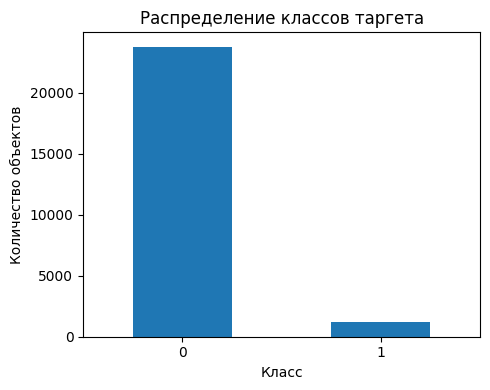

In [185]:
plt.figure(figsize=(5, 4))
target_counts.plot(kind="bar")
plt.title("Распределение классов таргета")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Формирование X и y

In [186]:
# Убираем таргет и идентификатор из признаков
X = df.drop(columns=["target", "id"])
y = df["target"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (25000, 60)
Shape y: (25000,)


## 2. Train/Test-сплит и воспроизводимость

Разделение данных на train / test

In [187]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (18750, 60) (18750,)
Test shape: (6250, 60) (6250,)


Проверка сохранения распределения классов

In [188]:
train_ratio = y_train.value_counts(normalize=True)
test_ratio = y_test.value_counts(normalize=True)

print("Train class distribution:")
print(train_ratio)

print("\nTest class distribution:")
print(test_ratio)

Train class distribution:
target
0    0.950773
1    0.049227
Name: proportion, dtype: float64

Test class distribution:
target
0    0.95088
1    0.04912
Name: proportion, dtype: float64


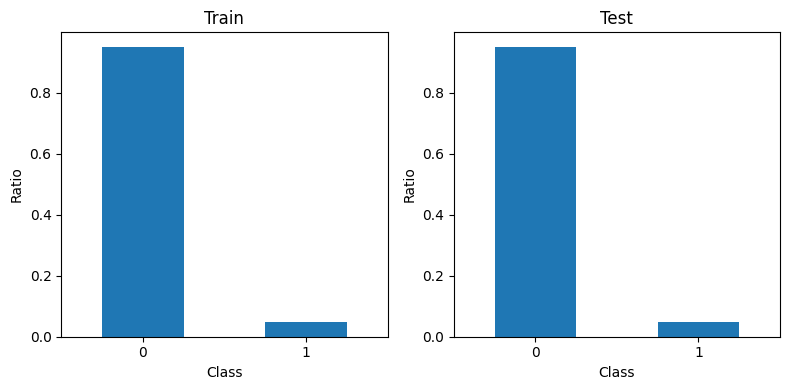

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

train_ratio.plot(kind="bar", ax=axes[0], title="Train")
test_ratio.plot(kind="bar", ax=axes[1], title="Test")

for ax in axes:
    ax.set_xlabel("Class")
    ax.set_ylabel("Ratio")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

Фиксация random_state обеспечивает воспроизводимость эксперимента: при повторном запуске ноутбука разбиение данных и, как следствие, результаты моделей остаются одинаковыми. Это критично для корректного сравнения алгоритмов и гиперпараметров.

Использование stratify=y гарантирует сохранение исходного распределения классов в обучающей и тестовой выборках. В условиях сильного дисбаланса классов это особенно важно, так как случайное разбиение без стратификации может привести к искажённой оценке качества модели, вплоть до отсутствия объектов миноритарного класса в одной из выборок.

## 3. Baseline’ы

In [190]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report, confusion_matrix
)

def evaluate_on_test(model, X_test, y_test, name="model"):
    y_pred = model.predict(X_test)

    # score для ROC-AUC / PR-AUC
    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_test, y_score)
        metrics["pr_auc"] = average_precision_score(y_test, y_score)
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    print(f"\n{name}")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

    return metrics

DummyClassifier

In [191]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

dummy_metrics = evaluate_on_test(dummy, X_test, y_test, name="Dummy")
dummy_metrics


Dummy
Confusion matrix:
 [[5943    0]
 [ 307    0]]
              precision    recall  f1-score   support

           0     0.9509    1.0000    0.9748      5943
           1     0.0000    0.0000    0.0000       307

    accuracy                         0.9509      6250
   macro avg     0.4754    0.5000    0.4874      6250
weighted avg     0.9042    0.9509    0.9269      6250



{'model': 'Dummy',
 'accuracy': 0.95088,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'pr_auc': 0.04912}

LogisticRegression через Pipeline(StandardScaler + LR)

In [192]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
])

lr_pipe.fit(X_train, y_train)

lr_metrics = evaluate_on_test(lr_pipe, X_test, y_test, name="LogReg")
lr_metrics


LogReg
Confusion matrix:
 [[4631 1312]
 [  68  239]]
              precision    recall  f1-score   support

           0     0.9855    0.7792    0.8703      5943
           1     0.1541    0.7785    0.2573       307

    accuracy                         0.7792      6250
   macro avg     0.5698    0.7789    0.5638      6250
weighted avg     0.9447    0.7792    0.8402      6250



{'model': 'LogReg',
 'accuracy': 0.7792,
 'precision': 0.15409413281753706,
 'recall': 0.7785016286644951,
 'f1': 0.2572658772874058,
 'roc_auc': 0.8418608704517014,
 'pr_auc': 0.45700182544850415}

1. DummyClassifier показывает «нижнюю планку»: при дисбалансе часто даёт высокую accuracy, но почти нулевой recall по редкому классу.
2. LogisticRegression — сильный линейный baseline: обычно заметно лучше Dummy по recall/F1/PR-AUC, но может проигрывать ансамблям на нелинейных зависимостях.

## 4. Модели недели 6

In [193]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def grid_search_train_only(estimator, param_grid, X_train, y_train, scoring="average_precision"):
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,  
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    gs.fit(X_train, y_train)
    return gs

DecisionTreeClassifier с контролем сложности

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")

dt_grid = {
    "max_depth": [2, 3, 4, 5, 7, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
}

dt_gs = grid_search_train_only(dt, dt_grid, X_train, y_train, scoring="average_precision")
print("Best DT params:", dt_gs.best_params_)
print("Best CV score (PR-AUC):", dt_gs.best_score_)



In [ ]:
dt_best = dt_gs.best_estimator_

print("DT best params (from estimator):")
print({k: dt_best.get_params()[k] for k in ["max_depth", "min_samples_leaf", "min_samples_split"]})

DT best params (from estimator):
{'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}


In [ ]:
dt_metrics = evaluate_on_test(dt_best, X_test, y_test, name="DecisionTree")
dt_metrics


DecisionTree
Confusion matrix:
 [[5171  772]
 [  96  211]]
              precision    recall  f1-score   support

           0     0.9818    0.8701    0.9226      5943
           1     0.2146    0.6873    0.3271       307

    accuracy                         0.8611      6250
   macro avg     0.5982    0.7787    0.6249      6250
weighted avg     0.9441    0.8611    0.8933      6250



{'model': 'DecisionTree',
 'accuracy': 0.86112,
 'precision': 0.21464903357070192,
 'recall': 0.6872964169381107,
 'f1': 0.3271317829457364,
 'roc_auc': 0.814797854317427,
 'pr_auc': 0.5767066899270448}

RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_fast = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_estimators=50,  
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_samples=0.7      
)

param_dist = {
    "max_depth": [None, 8, 12, 16],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": ["sqrt", 0.5],
}

rs = RandomizedSearchCV(
    rf_fast,
    param_distributions=param_dist,
    n_iter=10,  
    scoring="average_precision",
    cv=cv_fast,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
    verbose=1
)
rs.fit(X_train, y_train)

print("Best RF params:", rs.best_params_)
print("Best CV score (PR-AUC):", rs.best_score_)
rf_best = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_estimators=300,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_samples=0.7,
    **rs.best_params_
).fit(X_train, y_train)

rf_metrics = evaluate_on_test(rf_best, X_test, y_test, name="RandomForest")
rf_metrics

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF params: {'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 16}
Best CV score (PR-AUC): 0.7142325766684939

RandomForest
Confusion matrix:
 [[5936    7]
 [ 138  169]]
              precision    recall  f1-score   support

           0     0.9773    0.9988    0.9879      5943
           1     0.9602    0.5505    0.6998       307

    accuracy                         0.9768      6250
   macro avg     0.9688    0.7747    0.8439      6250
weighted avg     0.9764    0.9768    0.9738      6250



{'model': 'RandomForest',
 'accuracy': 0.9768,
 'precision': 0.9602272727272727,
 'recall': 0.5504885993485342,
 'f1': 0.6997929606625258,
 'roc_auc': 0.9066917474969869,
 'pr_auc': 0.7747404245764313}

HistGradientBoostingClassifier

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

hgb_grid = {
    "learning_rate": [0.03, 0.1, 0.2],
    "max_depth": [3, 5, None],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 50],
    "l2_regularization": [0.0, 0.1, 1.0],
}

hgb_gs = grid_search_train_only(hgb, hgb_grid, X_train, y_train, scoring="average_precision")
print("Best HGB params:", hgb_gs.best_params_)
print("Best CV score (PR-AUC):", hgb_gs.best_score_)

hgb_metrics = evaluate_on_test(hgb_gs.best_estimator_, X_test, y_test, name="HistGradientBoosting")
hgb_metrics

Best HGB params: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_depth': None, 'max_leaf_nodes': 31, 'min_samples_leaf': 50}
Best CV score (PR-AUC): 0.7632127910954695

HistGradientBoosting
Confusion matrix:
 [[5940    3]
 [ 118  189]]
              precision    recall  f1-score   support

           0     0.9805    0.9995    0.9899      5943
           1     0.9844    0.6156    0.7575       307

    accuracy                         0.9806      6250
   macro avg     0.9824    0.8076    0.8737      6250
weighted avg     0.9807    0.9806    0.9785      6250



{'model': 'HistGradientBoosting',
 'accuracy': 0.98064,
 'precision': 0.984375,
 'recall': 0.6156351791530945,
 'f1': 0.7575150300601202,
 'roc_auc': 0.9102022964087166,
 'pr_auc': 0.7978275358159795}

StackingClassifier

In [ ]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ("lr", lr_pipe),
        ("rf", rf_best),
        ("hgb", hgb_gs.best_estimator_),
    ],
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    cv=cv,
    n_jobs=1, 
    passthrough=False
)

stack.fit(X_train, y_train)

stack_metrics = evaluate_on_test(stack, X_test, y_test, name="Stacking (LR meta)")
stack_metrics


Stacking (LR meta)
Confusion matrix:
 [[5781  162]
 [  67  240]]
              precision    recall  f1-score   support

           0     0.9885    0.9727    0.9806      5943
           1     0.5970    0.7818    0.6770       307

    accuracy                         0.9634      6250
   macro avg     0.7928    0.8772    0.8288      6250
weighted avg     0.9693    0.9634    0.9657      6250



{'model': 'Stacking (LR meta)',
 'accuracy': 0.96336,
 'precision': 0.5970149253731343,
 'recall': 0.7817589576547231,
 'f1': 0.6770098730606487,
 'roc_auc': 0.9118794673173652,
 'pr_auc': 0.7966382311623135}

In [ ]:
results = pd.DataFrame([
    dummy_metrics,
    lr_metrics,
    dt_metrics,
    rf_metrics,
    hgb_metrics,
]).set_index("model").sort_values("pr_auc", ascending=False)

results

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
HistGradientBoosting,0.98064,0.984375,0.615635,0.757515,0.910202,0.797828
RandomForest,0.97680,0.960227,0.550489,0.699793,0.906692,0.774740
DecisionTree,0.86112,0.214649,0.687296,0.327132,0.814798,0.576707
"LogReg (scaled, balanced)",0.77920,0.154094,0.778502,0.257266,0.841861,0.457002
Dummy,0.95088,0.000000,0.000000,0.000000,0.500000,0.049120


## 5. Метрики качества

В качестве лучшей модели выбрана HistGradientBoostingClassifier, 
поскольку она показала наивысшее значение PR-AUC (0.79) и ROC-AUC (0.91) 
на тестовой выборке. Данная модель обеспечивает наилучший баланс между 
точностью и полнотой для редкого класса, что особенно важно в условиях 
сильного дисбаланса классов. По сравнению с RandomForest и одиночным 
деревом решений, boosting-модель демонстрирует более устойчивое и 
качественное обобщение.

In [ ]:
best_model = hgb_gs.best_estimator_
best_model_name = "HistGradientBoosting"

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)


def compute_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        raise ValueError("Модель не поддерживает predict_proba или decision_function")

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    }
    return metrics, y_pred, y_score

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score
)

def compute_metrics(model, X_test, y_test, name: str):
    y_pred = model.predict(X_test)

    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)

    metrics = {
        "model": name,
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_test, y_score)) if y_score is not None else None,
        "pr_auc": float(average_precision_score(y_test, y_score)) if y_score is not None else None,
    }
    return metrics

In [ ]:
rf_metrics = evaluate_on_test(rf_best, X_test, y_test, name="RandomForest")
rf_metrics


RandomForest
Confusion matrix:
 [[5936    7]
 [ 138  169]]
              precision    recall  f1-score   support

           0     0.9773    0.9988    0.9879      5943
           1     0.9602    0.5505    0.6998       307

    accuracy                         0.9768      6250
   macro avg     0.9688    0.7747    0.8439      6250
weighted avg     0.9764    0.9768    0.9738      6250



{'model': 'RandomForest',
 'accuracy': 0.9768,
 'precision': 0.9602272727272727,
 'recall': 0.5504885993485342,
 'f1': 0.6997929606625258,
 'roc_auc': 0.9066917474969869,
 'pr_auc': 0.7747404245764313}

ROC-кривая

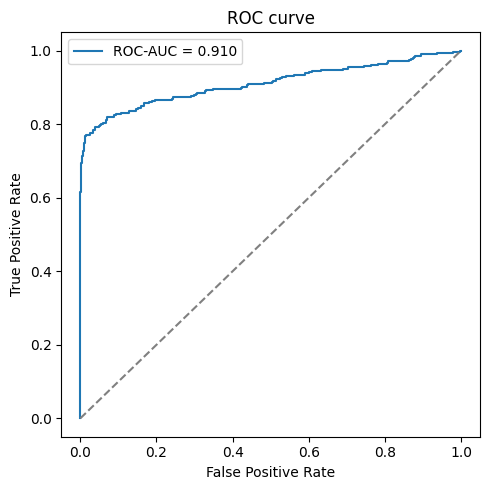

In [145]:
fpr, tpr, _ = roc_curve(y_test, rf_score)
roc_auc = roc_auc_score(y_test, rf_score)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curve.png", dpi=150)
plt.show()

PR-кривая

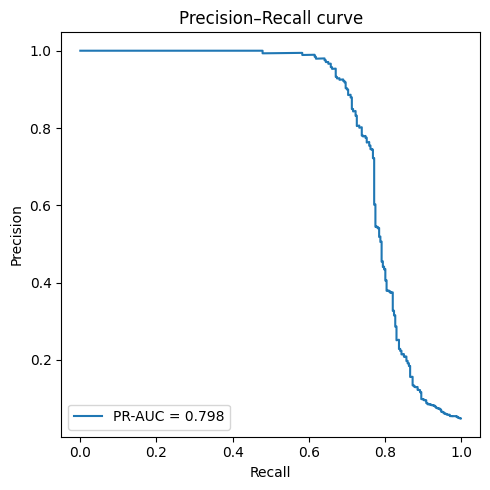

In [146]:
precision, recall, _ = precision_recall_curve(y_test, rf_score)
pr_auc = average_precision_score(y_test, rf_score)

plt.figure(figsize=(5, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr_curve.png", dpi=150)
plt.show()

Confusion matrix

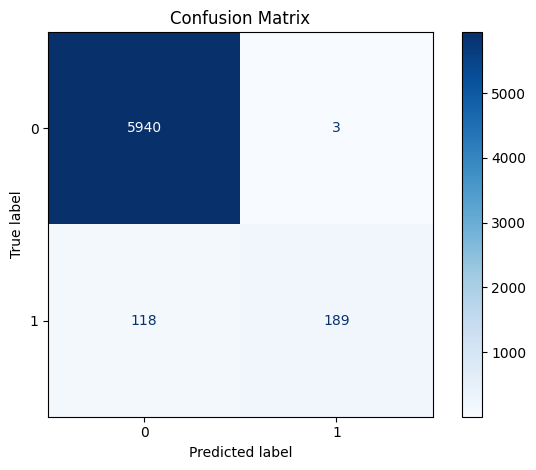

In [147]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, cmap="Blues"
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150)
plt.show()

Для бинарной классификации с сильным дисбалансом классов использование одной только accuracy некорректно, так как модель может игнорировать миноритарный класс.
Метрики F1, ROC-AUC и PR-AUC позволяют более адекватно оценить качество модели с точки зрения обнаружения редкого класса.

## 6. Интерпретация

Предположим, что лучшая модель это  best_model.

In [148]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="average_precision",
    n_jobs=-1
)

importances = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importances.head(15)

,feature,importance_mean,importance_std
53,f54,0.142860,0.014760
57,f58,0.140547,0.011402
24,f25,0.136031,0.008907
52,f53,0.070945,0.005466
37,f38,0.070608,0.006279
46,f47,0.058420,0.009281
10,f11,0.038744,0.003488
32,f33,0.037309,0.004148
3,f04,0.028151,0.002015
7,f08,0.022917,0.002984


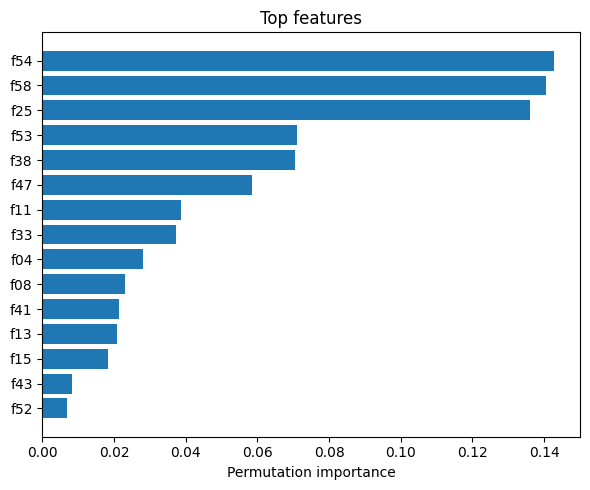

In [149]:
top_n = 15
plt.figure(figsize=(6, 5))
plt.barh(
    importances["feature"].head(top_n)[::-1],
    importances["importance_mean"].head(top_n)[::-1]
)
plt.xlabel("Permutation importance")
plt.title("Top features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "permutation_importance.png", dpi=150)
plt.show()

Перестановочная важность показывает, что наибольшее влияние на качество модели оказывают признаки f58, f54 и f25.
Это согласуется с ожиданиями по данным, поскольку данные признаки наиболее активно используются моделью при построении разделяющей границы между классами и, вероятно, отражают наиболее информативные комбинации входных переменных для выявления редкого класса.
Признаки с меньшей важностью либо содержат ограниченную информацию о целевой переменной, либо их вклад частично перекрывается более информативными признаками, что типично для ансамблевых моделей.

## 7. Артефакты эксперимента

In [174]:
import json

metrics_test = {
    "Dummy": dummy_metrics,
    "LogReg": lr_metrics,
    "DecisionTree": dt_metrics,
    "RandomForest": rf_metrics,
    "HistGradientBoosting": hgb_metrics,
}

with open(ARTIFACTS_DIR / "metrics_test.json", "w") as f:
    json.dump(metrics_test, f, indent=2)

In [164]:
search_summaries = {
    "DecisionTree": {
        "best_params": dt_gs.best_params_,
        "cv_score": dt_gs.best_score_,
    },
    "RandomForest": {
        "best_params": rs.best_params_,
        "cv_score": rs.best_score_,
    },
    "HistGradientBoosting": {
        "best_params": hgb_gs.best_params_,
        "cv_score": hgb_gs.best_score_,
    },
}

with open(ARTIFACTS_DIR / "search_summaries.json", "w") as f:
    json.dump(search_summaries, f, indent=2)

In [152]:
import joblib

joblib.dump(best_model, ARTIFACTS_DIR / "best_model.joblib")

['artifacts/best_model.joblib']

In [165]:
best_model_meta = {
    "model_name": "HistGradientBoosting",
    "params": hgb_gs.best_params_,
    "test_metrics": hgb_metrics,
    "selection_criterion": "PR-AUC"
}

with open(ARTIFACTS_DIR / "best_model_meta.json", "w") as f:
    json.dump(best_model_meta, f, indent=2)